In [61]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [62]:
# spliz tabula sapien matrix from: https://figshare.com/articles/dataset/Tabula_Sapiens_Splicing/14977281
ts_spliz = '/gpfs/commons/groups/knowles_lab/Karin/data/TabulaSapiens/SpliZ_output/28835343'

In [63]:
# read in ts_spliz as h5ad file
ts_spliz = sc.read_h5ad(ts_spliz)

In [64]:
# For each cell, a splicing score, called the SpliZ, is assigned to each gene with enough informative splicing information (Olivieri et. al. 2021). 
# This object contains both gene expression values (labeled with the gene name, e.g. “MYL6”) and splicing values (labeled with the gene name and “SpliZ”, e.g. “MYL6_SpliZ”). 
# To get just the splicing values let's subset the adata object to the vars that have the suffix SpliZ.

ts_spliz.var_names.str.endswith('SpliZ')

array([False, False, False, ...,  True,  True,  True])

In [65]:
ts_spliz

AnnData object with n_obs × n_vars = 98406 × 60636
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender'
    var: 'gene_symbol-0', 'feature_type-0', 'ensemblid-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'mean-0', 'std-0', 'gene_symbol-1', 'feature_type-1', 'ensemblid-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'mean-1', 'std-1'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'

In [66]:
# keep just variables in the adata object that end in "SpliZ"
# Step 1: Find the variable names (genes) that end in "SpliZ"
spliz_genes = ts_spliz.var_names[ts_spliz.var_names.str.endswith("SpliZ")]

# Step 2: Subset the AnnData object using only the "SpliZ" genes
adata_subset = ts_spliz[:, spliz_genes].copy()

# Display the subsetted AnnData object
print(adata_subset)

AnnData object with n_obs × n_vars = 98406 × 1766
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender'
    var: 'gene_symbol-0', 'feature_type-0', 'ensemblid-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'mean-0', 'std-0', 'gene_symbol-1', 'feature_type-1', 'ensemblid-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'mean-1', 'std-1'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'


In [67]:
adata_subset.var_names[adata_subset.var_names.str.startswith('unknown')]

Index(['unknown_chr10_73600000_SpliZ', 'unknown_chr12_47200000_SpliZ',
       'unknown_chr17_29500000_SpliZ', 'unknown_chr1_231500000_SpliZ',
       'unknown_chr21_8900000_SpliZ', 'unknown_chr22_22700000_SpliZ',
       'unknown_chr22_22900000_SpliZ', 'unknown_chr2_88900000_SpliZ',
       'unknown_chr2_89000000_SpliZ', 'unknown_chr2_89200000_SpliZ',
       'unknown_chr2_89300000_SpliZ', 'unknown_chr3_48900000_SpliZ',
       'unknown_chr4_73900000_SpliZ', 'unknown_chr6_26100000_SpliZ',
       'unknown_chr7_67900000_SpliZ', 'unknown_chr9_77100000_SpliZ',
       'unknown_chrM_0_SpliZ'],
      dtype='object')

In [68]:
# Create a boolean mask to filter out the genes starting with "unknown"
mask_unknown = ~adata_subset.var_names.str.startswith('unknown')

# Filter the AnnData object to keep only the desired genes
adata_subset = adata_subset[:, mask_unknown].copy()

# Display the updated subsetted AnnData object
print(adata_subset)

AnnData object with n_obs × n_vars = 98406 × 1749
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender'
    var: 'gene_symbol-0', 'feature_type-0', 'ensemblid-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'mean-0', 'std-0', 'gene_symbol-1', 'feature_type-1', 'ensemblid-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'mean-1', 'std-1'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'


In [69]:
adata_subset.var

,gene_symbol-0,feature_type-0,ensemblid-0,highly_variable-0,means-0,dispersions-0,dispersions_norm-0,mean-0,std-0,gene_symbol-1,feature_type-1,ensemblid-1,highly_variable-1,means-1,dispersions-1,dispersions_norm-1,mean-1,std-1
A2M_SpliZ,A2M,Gene Expression,ENSG00000175899.14,1.0,1.054211,5.480701,2.477780,0.307667,0.795199,A2M,Gene Expression,ENSG00000175899.14,1.0,1.054211,5.480701,2.477780,0.307667,0.795199
AAMDC_SpliZ,AAMDC,Gene Expression,ENSG00000087884.14,0.0,0.265232,0.898246,-0.530411,0.171903,0.370291,AAMDC,Gene Expression,ENSG00000087884.14,0.0,0.265232,0.898246,-0.530411,0.171903,0.370291
ABCA6_SpliZ,ABCA6,Gene Expression,ENSG00000154262.13,0.0,0.254027,2.107684,0.302716,0.116552,0.392420,ABCA6,Gene Expression,ENSG00000154262.13,0.0,0.254027,2.107684,0.302716,0.116552,0.392420
ABCA9_SpliZ,ABCA9,Gene Expression,ENSG00000154258.17,0.0,0.191486,1.698168,0.020619,0.089273,0.340729,ABCA9,Gene Expression,ENSG00000154258.17,0.0,0.191486,1.698168,0.020619,0.089273,0.340729
ABCE1_SpliZ,ABCE1,Gene Expression,ENSG00000164163.11,0.0,0.361785,1.008532,-0.689420,0.239226,0.431520,ABCE1,Gene Expression,ENSG00000164163.11,0.0,0.361785,1.008532,-0.689420,0.239226,0.431520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF706_SpliZ,ZNF706,Gene Expression,ENSG00000120963.12,0.0,0.805628,1.085138,-0.699351,0.591835,0.620697,ZNF706,Gene Expression,ENSG00000120963.12,0.0,0.805628,1.085138,-0.699351,0.591835,0.620697
ZNHIT1_SpliZ,ZNHIT1,Gene Expression,ENSG00000106400.12,0.0,0.678361,0.838989,-0.920098,0.493431,0.572383,ZNHIT1,Gene Expression,ENSG00000106400.12,0.0,0.678361,0.838989,-0.920098,0.493431,0.572383
ZRANB2_SpliZ,ZRANB2,Gene Expression,ENSG00000132485.14,0.0,0.660046,1.365246,-0.448151,0.460631,0.575900,ZRANB2,Gene Expression,ENSG00000132485.14,0.0,0.660046,1.365246,-0.448151,0.460631,0.575900
ZRSR2_SpliZ,ZRSR2,Gene Expression,ENSG00000169249.12,0.0,0.189477,1.489712,-0.122977,0.113902,0.318342,ZRSR2,Gene Expression,ENSG00000169249.12,0.0,0.189477,1.489712,-0.122977,0.113902,0.318342


In [70]:
adata_subset

AnnData object with n_obs × n_vars = 98406 × 1749
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender'
    var: 'gene_symbol-0', 'feature_type-0', 'ensemblid-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'mean-0', 'std-0', 'gene_symbol-1', 'feature_type-1', 'ensemblid-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'mean-1', 'std-1'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'

In [71]:
adata_subset.X.toarray().shape

(98406, 1749)

In [72]:
adata_subset.X.toarray()[0,:]

array([nan, nan, nan, ..., nan, nan, nan], dtype=float32)

In [73]:
adata_subset.X.toarray()[1:]

array([[-0.20689614,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], dtype=float32)

In [74]:
adata_subset

AnnData object with n_obs × n_vars = 98406 × 1749
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender'
    var: 'gene_symbol-0', 'feature_type-0', 'ensemblid-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'mean-0', 'std-0', 'gene_symbol-1', 'feature_type-1', 'ensemblid-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'mean-1', 'std-1'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'

In [75]:
# save adata_subset as dataframe 
adata_subset_df = adata_subset.to_df()
adata_subset_df.head()

,A2M_SpliZ,AAMDC_SpliZ,ABCA6_SpliZ,ABCA9_SpliZ,ABCE1_SpliZ,ABI3BP_SpliZ,ACAP1_SpliZ,ACAP2_SpliZ,ACD_SpliZ,ACRBP_SpliZ,...,ZNF326_SpliZ,ZNF331_SpliZ,ZNF385D_SpliZ,ZNF480_SpliZ,ZNF638_SpliZ,ZNF706_SpliZ,ZNHIT1_SpliZ,ZRANB2_SpliZ,ZRSR2_SpliZ,ZSWIM7_SpliZ
cell_id,,,,,,,,,,,,,,,,,,,,,
AAACCCAGTCCTATAG_TSP2_Bladder_NA_10X_1_1-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACGAACAGCGGTCT_TSP2_Bladder_NA_10X_1_1-0,-0.206896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACGCTGTGTTTGCA_TSP2_Bladder_NA_10X_1_1-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAAGAACAGGTACAGC_TSP2_Bladder_NA_10X_1_1-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAAGAACCAGAGATTA_TSP2_Bladder_NA_10X_1_1-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
# add cell type annotation to adata_subset_df
adata_subset_df["organ_tissue"] = adata_subset.obs["organ_tissue"].astype("category")
adata_subset_df["donor"] = adata_subset.obs["donor"].astype("category")
adata_subset_df["cell_ontology_class"] = adata_subset.obs["cell_ontology_class"].astype("category")
adata_subset_df["compartment"] = adata_subset.obs["compartment"].astype("category")

In [77]:
adata_subset_df.head()

,A2M_SpliZ,AAMDC_SpliZ,ABCA6_SpliZ,ABCA9_SpliZ,ABCE1_SpliZ,ABI3BP_SpliZ,ACAP1_SpliZ,ACAP2_SpliZ,ACD_SpliZ,ACRBP_SpliZ,...,ZNF638_SpliZ,ZNF706_SpliZ,ZNHIT1_SpliZ,ZRANB2_SpliZ,ZRSR2_SpliZ,ZSWIM7_SpliZ,organ_tissue,donor,cell_ontology_class,compartment
cell_id,,,,,,,,,,,,,,,,,,,,,
AAACCCAGTCCTATAG_TSP2_Bladder_NA_10X_1_1-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Bladder,TSP2,plasma cell,immune
AAACGAACAGCGGTCT_TSP2_Bladder_NA_10X_1_1-0,-0.206896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Bladder,TSP2,bladder urothelial cell,epithelial
AAACGCTGTGTTTGCA_TSP2_Bladder_NA_10X_1_1-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Bladder,TSP2,fibroblast,stromal
AAAGAACAGGTACAGC_TSP2_Bladder_NA_10X_1_1-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Bladder,TSP2,bladder urothelial cell,epithelial
AAAGAACCAGAGATTA_TSP2_Bladder_NA_10X_1_1-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Bladder,TSP2,bladder urothelial cell,epithelial


In [78]:
MYL6 = adata_subset_df[["MYL6_SpliZ", "organ_tissue", "donor", "cell_ontology_class", "compartment"]]

In [79]:
MYL6.organ_tissue.unique()

['Bladder', 'Blood', 'Bone_Marrow', 'Large_Intestine', 'Lung', ..., 'Small_Intestine', 'Spleen', 'Thymus', 'Trachea', 'Vasculature']
Length: 12
Categories (12, object): ['Bladder', 'Blood', 'Bone_Marrow', 'Large_Intestine', ..., 'Spleen', 'Thymus', 'Trachea', 'Vasculature']

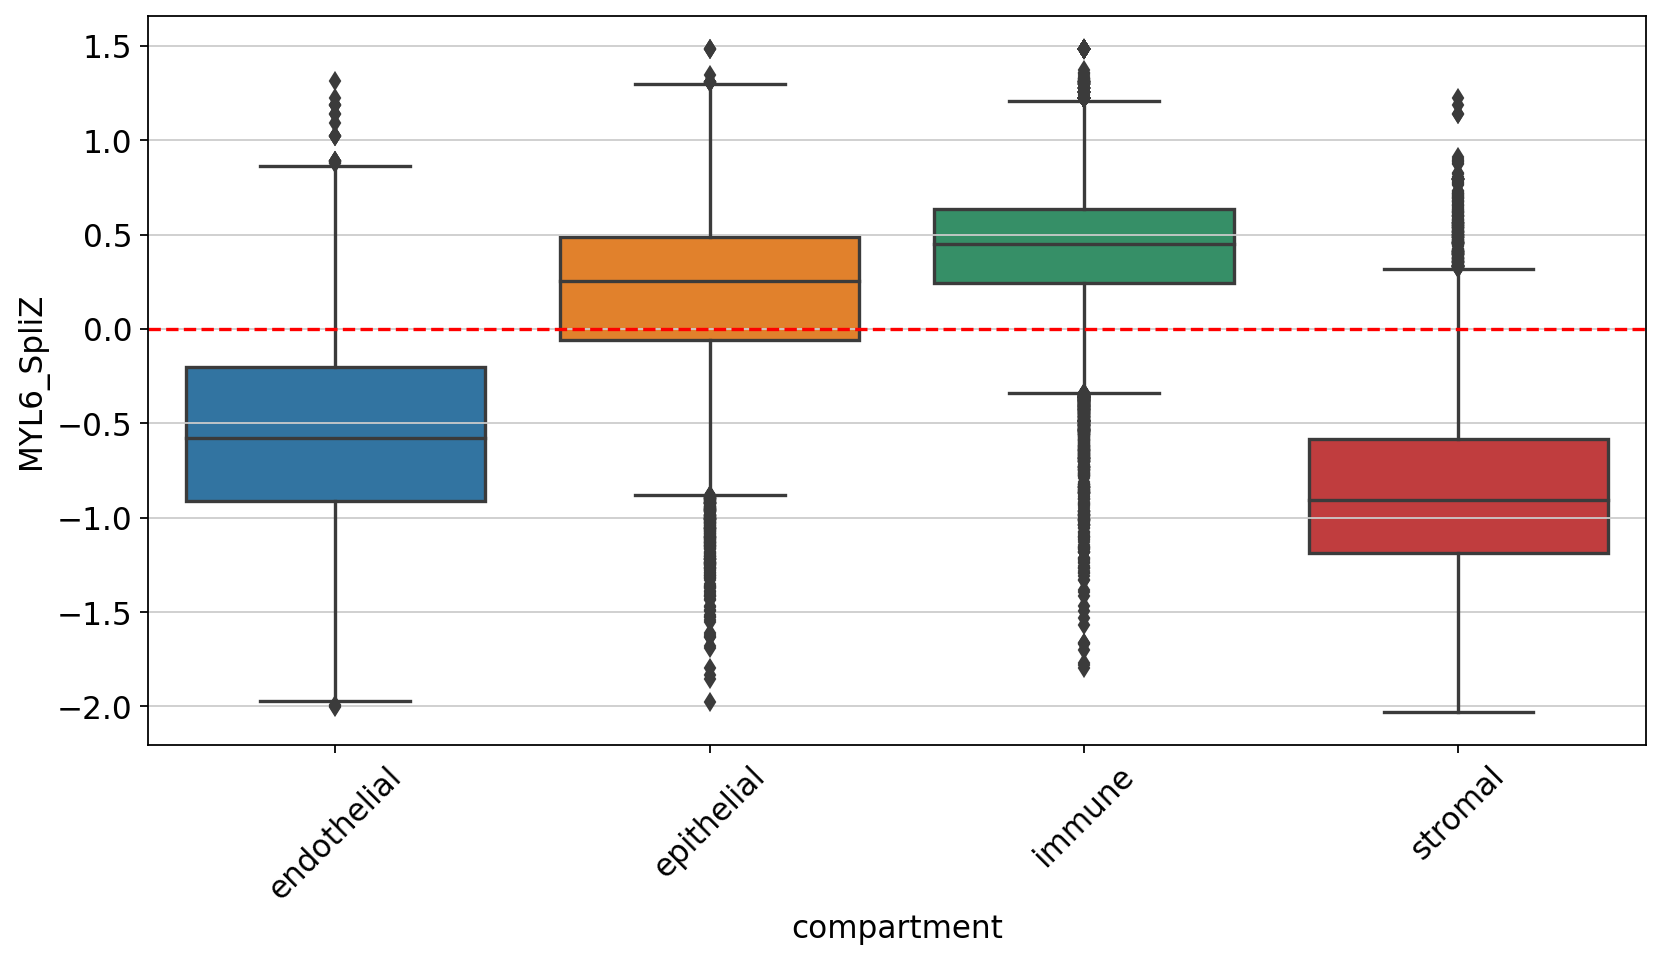

In [80]:
# make a plot of MYL6 values that are not NaN by organ_tissue
plt.figure(figsize=(12, 6))  # Adjust the width (12) and height (6) as needed
sns.boxplot(x='compartment', y='MYL6_SpliZ', data=MYL6)
# add a dotted red line at y-axis value 0
plt.axhline(y=0, linestyle='--', color='red')
plt.xticks(rotation=45)
plt.show()

In [81]:
# check which directory im in 
!pwd

/gpfs/commons/home/kisaev/Leaflet-analysis/tabula_sapien


In [82]:
# save dataframe as csv
adata_subset_df.to_csv("/gpfs/commons/groups/knowles_lab/Karin/data/TabulaSapiens/SpliZ_output/adata_subset_df.csv")